In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("aug_train.csv")
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [7]:
df.shape

(19158, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 2.

In [9]:
df.describe(include="all")

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
count,19158.000000,19158,19158.000000,14650,19158,18772,18698,16345,19093,13220,13018,18735,19158.000000,19158.000000
unique,NaN,123,NaN,3,2,3,5,6,22,8,6,6,NaN,NaN
top,NaN,city_103,NaN,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,NaN,NaN
freq,NaN,4355,NaN,13221,13792,13817,11598,14492,3286,3083,9817,8040,NaN,NaN
mean,16875.358179,NaN,0.828848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.366896,0.249348
std,9616.292592,NaN,0.123362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.058462,0.432647
min,1.000000,NaN,0.448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,8554.250000,NaN,0.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,0.000000
50%,16982.500000,NaN,0.903000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.000000,0.000000
75%,25169.750000,NaN,0.920000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.000000,0.000000


In [10]:
df.columns.tolist()

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours',
 'target']

In [11]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
]

missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
company_type,6140,32.05
company_size,5938,30.99
gender,4508,23.53
major_discipline,2813,14.68
education_level,460,2.40
last_new_job,423,2.21
enrolled_university,386,2.01
experience,65,0.34


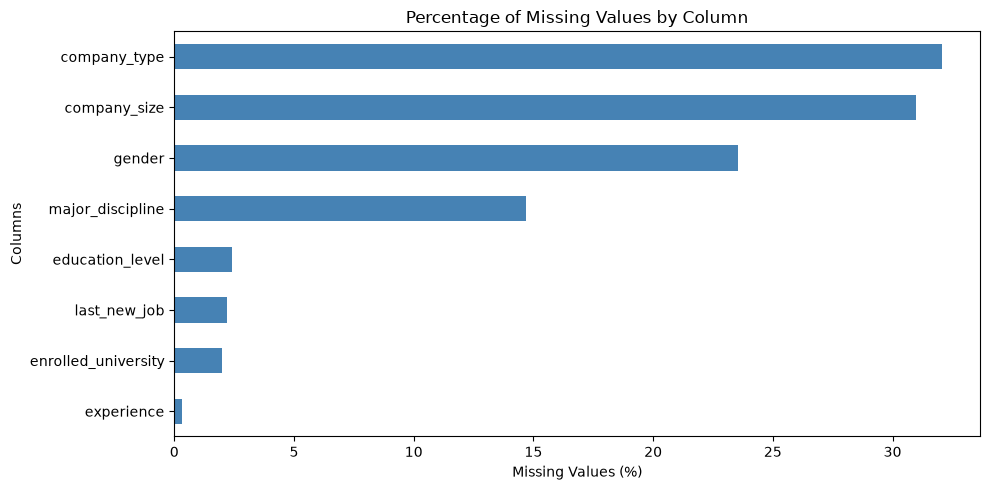

In [15]:
plt.figure(figsize=(10, 5))

missing_values["Missing Percentage"].sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

In [16]:
print("Rows with at least one missing value:",
      df.isnull().any(axis=1).sum())

print("Rows with no missing values:",
      df.notnull().all(axis=1).sum())

Rows with at least one missing value: 10203
Rows with no missing values: 8955


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["enrollee_id"].duplicated().sum()

np.int64(0)

In [19]:
df["experience"].unique()


<StringArray>
['>20',  '15',   '5',  '<1',  '11',  '13',   '7',  '17',   '2',  '16',   '1',
   '4',  '10',  '14',  '18',  '19',  '12',   '3',   '6',   '9',   '8',  '20',
   nan]
Length: 23, dtype: str

In [20]:
df["last_new_job"].unique()

<StringArray>
['1', '>4', 'never', '4', '3', '2', nan]
Length: 7, dtype: str

In [21]:
df["target"].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

In [22]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [24]:
# Education levels of candidates with missing major discipline
df[df["major_discipline"].isnull()]["education_level"].value_counts(dropna=False)

education_level
High School       2017
NaN                460
Primary School     308
Graduate            22
Masters              6
Name: count, dtype: int64

In [26]:
df_clean = df.copy()

In [28]:
# Candidates with primary or high school education
df_clean.loc[
    df_clean["education_level"] == "Primary School",
    "major_discipline"
] = "Not Applicable"

df_clean.loc[
    df_clean["education_level"] == "High School",
    "major_discipline"
] = "Not Applicable"

In [29]:
# Fill the remaining missing majors
df_clean["major_discipline"] = df_clean["major_discipline"].fillna("Unknown")

In [30]:
df_clean["major_discipline"].isnull().sum()

np.int64(0)

In [ ]:
**Problem: Missing Values in major_discipline**

The `major_discipline` column contains 2,813 missing values.

After checking the relationship with `education_level`, we found that most missing values belong to candidates with High School or Primary School education.

**Solution:** Replace missing majors with "Not Applicable" for candidates with school-level education and "Unknown" for the remaining missing values.

**Justification:** A university major does not normally apply to candidates without university education. For other candidates, the information is missing, so we should not guess their major.

This solution preserves the dataset without deleting rows.

In [31]:
# Check missing company size by work experience
pd.crosstab(
    df["relevent_experience"],
    df["company_size"].isnull()
)

company_size,False,True
relevent_experience,,
Has relevent experience,11211,2581
No relevent experience,2009,3357


In [32]:
# Check missing company type by work experience
pd.crosstab(
    df["relevent_experience"],
    df["company_type"].isnull()
)

company_type,False,True
relevent_experience,,
Has relevent experience,10815,2977
No relevent experience,2203,3163


In [34]:
# Fill missing company information
df_clean["company_size"] = df_clean["company_size"].fillna("Unknown")
df_clean["company_type"] = df_clean["company_type"].fillna("Unknown")

In [35]:
# Check remaining missing values
df_clean[["company_size", "company_type"]].isnull().sum()

company_size    0
company_type    0
dtype: int64

In [ ]:
**Problem: Missing Company Information**

The `company_size` column contains 5,938 missing values (30.99%), and `company_type` contains 6,140 missing values (32.05%).

After comparing these columns with `relevent_experience`, we found that missing values are more frequent among candidates without relevant experience.

**Solution:** Replace missing values with "Unknown".

**Justification:** We cannot know whether the candidate has no employer or simply did not provide this information. Using "Unknown" avoids making incorrect assumptions and allows us to keep all the rows.

In [36]:
# Check gender categories
df["gender"].value_counts(dropna=False)

gender
Male      13221
NaN        4508
Female     1238
Other       191
Name: count, dtype: int64

In [37]:
# Replace missing gender values
df_clean["gender"] = df_clean["gender"].fillna("Unknown")

In [38]:
# Check if there are still missing values
df_clean["gender"].isnull().sum()

np.int64(0)

In [ ]:
**Problem: Missing Gender Values**

The `gender` column contains 4,508 missing values (23.53%).

The existing categories are Male, Female, and Other.

**Solution:** Replace missing values with "Unknown".

**Justification:** Replacing missing values with the most frequent category (Male) could introduce bias. Deleting the rows would result in significant data loss. Using "Unknown" preserves all candidates without assuming their gender.

In [40]:
# Check education levels
df["education_level"].value_counts(dropna=False)

education_level
Graduate          11598
Masters            4361
High School        2017
NaN                 460
Phd                 414
Primary School      308
Name: count, dtype: int64

In [41]:
# Fill missing education levels
df_clean["education_level"] = df_clean["education_level"].fillna("Unknown")

In [42]:
df_clean["education_level"].isnull().sum()

np.int64(0)

In [ ]:
**Problem: Missing Education Levels**

The `education_level` column contains 460 missing values (2.40%).

No inconsistent categories were detected.

**Solution:** Replace missing values with "Unknown".

**Justification:** Although Graduate is the most frequent education level, using it to fill missing values could introduce incorrect information. Replacing missing values with "Unknown" preserves the original records without making assumptions.

In [43]:
# Check university enrollment categories
df["enrolled_university"].value_counts(dropna=False)

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
NaN                   386
Name: count, dtype: int64

In [45]:
# Fill missing university enrollment values
df_clean["enrolled_university"] = df_clean["enrolled_university"].fillna("Unknown")

In [46]:
# Check remaining missing values
df_clean["enrolled_university"].isnull().sum()

np.int64(0)

In [ ]:
**Problem: Missing University Enrollment Values**

The `enrolled_university` column contains 386 missing values (2.01%).

The existing categories are no_enrollment, Full time course, and Part time course.

**Solution:** Replace missing values with "Unknown".

**Justification:** Although no_enrollment is the most common category, we cannot assume that candidates with missing values are not enrolled. Using "Unknown" preserves all records without introducing potentially incorrect information.

In [47]:
# Check experience categories and their frequencies
df["experience"].value_counts(dropna=False)

experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
NaN      65
Name: count, dtype: int64

In [48]:
# Fill missing experience values
df_clean["experience"] = df_clean["experience"].fillna("Unknown")

In [49]:
df_clean["experience"].isnull().sum()

np.int64(0)

In [50]:
df_clean["experience"].isnull().sum()

np.int64(0)

In [ ]:
**Problem: Missing Experience Values**

The `experience` column contains 65 missing values (0.34%).

The values range from less than 1 year to more than 20 years of experience.

**Solution:** Replace missing values with "Unknown".

**Justification:** The most frequent value is ">20", but using it would incorrectly assume that candidates with missing information have more than 20 years of experience. "Unknown" preserves the records without introducing potentially false information.

In [52]:
# Check the distribution of last_new_job
df["last_new_job"].value_counts(dropna=False)

last_new_job
1        8040
>4       3290
2        2900
never    2452
4        1029
3        1024
NaN       423
Name: count, dtype: int64

In [53]:
# Fill missing last_new_job values
df_clean["last_new_job"] = df_clean["last_new_job"].fillna("Unknown")

In [54]:
df_clean["last_new_job"].isnull().sum()

np.int64(0)

In [ ]:
### Problem: Missing Last New Job Values

**Observation:** The `last_new_job` column contains 423 missing values (2.21%).

**Solution:** Replace missing values with "Unknown".

**Justification:** The most frequent value is "1", but replacing missing values with it could introduce incorrect information. Using "Unknown" preserves all rows without making assumptions.

In [55]:
df_clean.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [56]:
# Compare dataset sizes
print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

Original dataset: (19158, 14)
Cleaned dataset: (19158, 14)


In [57]:
df["company_size"].value_counts(dropna=False)

company_size
NaN          5938
50-99        3083
100-500      2571
10000+       2019
10/49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

In [58]:
# Standardize company size format
df_clean["company_size"] = df_clean["company_size"].replace("10/49", "10-49")

In [59]:
# Check company size categories after cleaning
df_clean["company_size"].value_counts()

company_size
Unknown      5938
50-99        3083
100-500      2571
10000+       2019
10-49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

In [ ]:
### Problem: Inconsistent Company Size Format

**Observation:** The `company_size` column contains employee ranges with different separators, such as "10/49" and "50-99".

**Solution:** Replace "10/49" with "10-49".

**Justification:** Using a consistent format makes the categories easier to understand and process. The meaning of the original category is preserved.

In [61]:
# Check company type categories
df["company_type"].value_counts(dropna=False)

company_type
Pvt Ltd                9817
NaN                    6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

In [62]:
# Check the number of different cities
df["city"].nunique()

123

In [63]:
# Display some city values
df["city"].unique()[:20]

<StringArray>
['city_103',  'city_40',  'city_21', 'city_115', 'city_162', 'city_176',
 'city_160',  'city_46',  'city_61', 'city_114',  'city_13', 'city_159',
 'city_102',  'city_67', 'city_100',  'city_16',  'city_71', 'city_104',
  'city_64', 'city_101']
Length: 20, dtype: str

In [64]:
# Find city values that do not start with "city_"
df[~df["city"].str.startswith("city_")]["city"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [65]:
# Check city identifiers that do not follow city_number format
df[~df["city"].str.match(r"^city_\d+$")]["city"].unique()

<StringArray>
[]
Length: 0, dtype: str

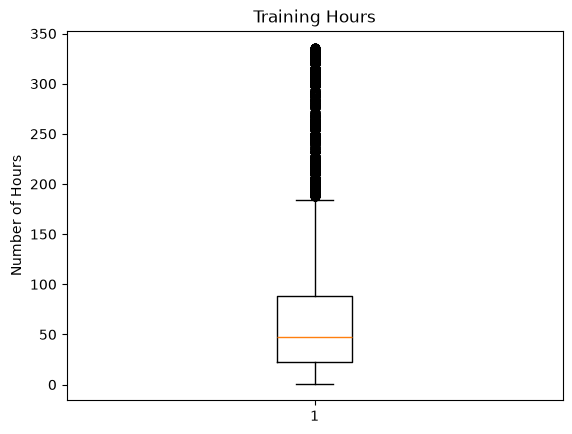

In [66]:
# Visualize training hours
plt.boxplot(df["training_hours"])
plt.title("Training Hours")
plt.ylabel("Number of Hours")
plt.show()

In [67]:
# Show the 10 highest training hours
df["training_hours"].sort_values(ascending=False).head(10)

4794     336
7121     336
4397     336
13929    336
13753    336
18458    336
4117     336
15615    336
2056     336
16785    336
Name: training_hours, dtype: int64

In [ ]:
### Problem: Potential Outliers in Training Hours

**Observation:** The boxplot shows several unusually high training-hour values. The maximum is 336 hours, compared with a median of 47 hours.

**Justification:** High training hours may represent valid observations. Removing them without verification could result in the loss of useful information.

In [70]:
# Check invalid training hours
df[df["training_hours"] <= 0]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target


In [71]:
# Check invalid city development index values
df[(df["city_development_index"] < 0) |
   (df["city_development_index"] > 1)]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target


In [72]:
# Check invalid target values
df[~df["target"].isin([0, 1])]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target


In [73]:
# Compare education level with major discipline
pd.crosstab(
    df["education_level"],
    df["major_discipline"],
    dropna=False
)

major_discipline,Arts,Business Degree,Humanities,No Major,Other,STEM,NaN
education_level,,,,,,,
Graduate,208,238,420,194,272,10244,22
High School,0,0,0,0,0,0,2017
Masters,42,86,225,29,100,3873,6
Phd,3,3,24,0,9,375,0
Primary School,0,0,0,0,0,0,308
NaN,0,0,0,0,0,0,460


In [ ]:
### Education and Major Discipline Consistency

**Observation:** All candidates with Primary School or High School education have missing major disciplines. Only 28 Graduate and Masters candidates have missing majors.

**Solution:** Use "Not Applicable" for school-level candidates and "Unknown" for the remaining missing values.

**Justification:** A university major is not applicable to school-level education. Missing majors for university graduates cannot be determined without additional information.

In [74]:
# Check for remaining missing values
df_clean.isnull().sum()

enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

In [75]:
# Check dataset dimensions
df_clean.shape

(19158, 14)

In [76]:
# Compare missing values before and after cleaning
comparison = pd.DataFrame({
    "Before Cleaning": df.isnull().sum(),
    "After Cleaning": df_clean.isnull().sum()
})

comparison

,Before Cleaning,After Cleaning
enrollee_id,0,0
city,0,0
city_development_index,0,0
gender,4508,0
relevent_experience,0,0
enrolled_university,386,0
education_level,460,0
major_discipline,2813,0
experience,65,0
company_size,5938,0


In [77]:
# Check if we lost any rows during cleaning
print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (19158, 14)
After cleaning: (19158, 14)


In [78]:
# Check company size categories after cleaning
df_clean["company_size"].value_counts()

company_size
Unknown      5938
50-99        3083
100-500      2571
10000+       2019
10-49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64

In [ ]:
### Data Cleaning Summary

The dataset initially contained missing values in eight columns.

**Problems detected:**
- Missing values in several categorical columns.
- Inconsistent formatting in `company_size`.
- Potential outliers in `training_hours`.

**Solutions applied:**
- Replaced missing values with "Unknown" when the original information could not be determined.
- Used "Not Applicable" for major disciplines that do not apply to school-level education.
- Standardized the company size category "10/49" to "10-49".
- Kept potential training-hour outliers because there was no evidence that they were incorrect.

**Results:**
- No remaining NaN values.
- No duplicate rows or candidate IDs were detected.
- The dataset still contains 19,158 rows and 14 columns.
- The original dataset was preserved separately for comparison.

**Conclusion:** The cleaning improved data consistency and provided explicit labels for missing information without removing observations. However, values marked as "Unknown" still represent unavailable information.

In [80]:
# Save cleaned dataset as a CSV file
df_clean.to_csv("aug_train_cleaned.csv", index=False)

In [81]:
# Statistics after data cleaning
df_clean.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [82]:
# Select numerical columns for analysis
df_clean[["city_development_index", "training_hours"]].describe()

,city_development_index,training_hours
count,19158.000000,19158.000000
mean,0.828848,65.366896
std,0.123362,60.058462
min,0.448000,1.000000
25%,0.740000,23.000000
50%,0.903000,47.000000
75%,0.920000,88.000000
max,0.949000,336.000000


In [83]:
# Mean and median of training hours
print("Mean:", df_clean["training_hours"].mean())
print("Median:", df_clean["training_hours"].median())

Mean: 65.36689633573442
Median: 47.0


In [ ]:
### Statistical Analysis After Data Cleaning

**Objective:** Analyze the numerical variables after handling missing values and inconsistent categories.

**Method:** Use descriptive statistics to examine the mean, median, minimum, maximum, and standard deviation.

**Interpretation:** The training-hours distribution appears positively skewed because its mean is higher than its median. Some candidates have considerably more training hours than others.

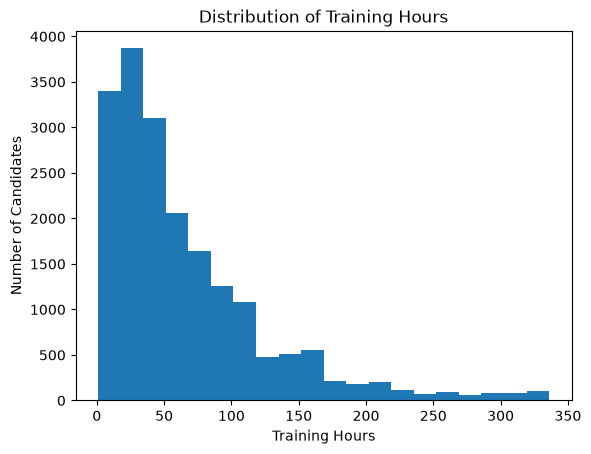

In [84]:
# Distribution of training hours
plt.hist(df_clean["training_hours"], bins=20)

plt.title("Distribution of Training Hours")
plt.xlabel("Training Hours")
plt.ylabel("Number of Candidates")

plt.show()

In [85]:
# Count candidates by education level
df_clean["education_level"].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Unknown             460
Phd                 414
Primary School      308
Name: count, dtype: int64

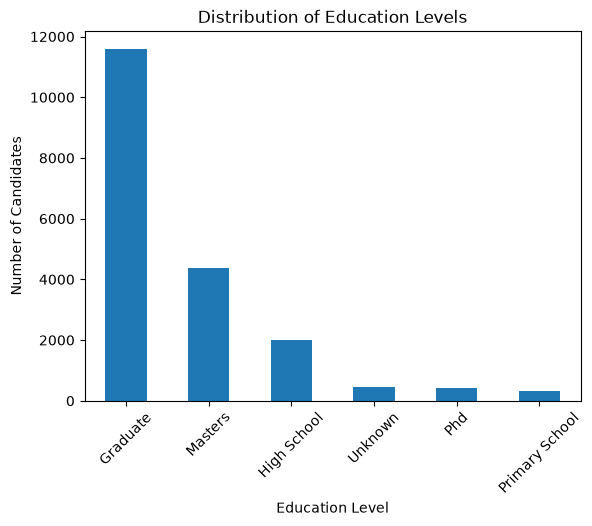

In [86]:
# Education level distribution
df_clean["education_level"].value_counts().plot(kind="bar")

plt.title("Distribution of Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=45)
plt.show()

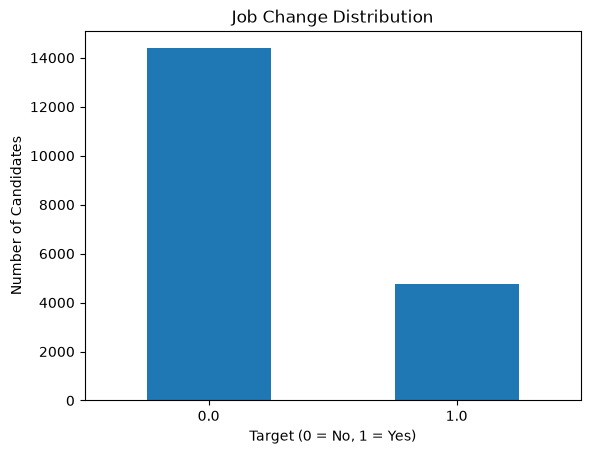

In [87]:
# Distribution of target values
df_clean["target"].value_counts().plot(kind="bar")

plt.title("Job Change Distribution")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=0)
plt.show()

In [ ]:
### Statistical Visualizations

**Training Hours:** A histogram is used to examine how training hours are distributed and to identify whether most candidates have low or high training durations.

**Education Level:** A bar chart is used to compare the number of candidates at each education level. Graduate is the most common category.

**Target Variable:** The target distribution shows that 75.1% of candidates are not looking for a job change, while 24.9% are looking for one. This indicates an imbalance between the two classes.

In [ ]:
### Training Hours Distribution

The histogram shows that most candidates have fewer than 100 training hours.

The distribution is right-skewed, meaning that a smaller number of candidates have much higher training hours.

These high values may be valid, so they were kept during data cleaning.

In [ ]:
### Education Level Distribution

Most candidates have a Graduate education level, followed by Masters.

High School, PhD, and Primary School candidates represent smaller groups.

The Unknown category contains candidates whose education level was not provided in the original dataset.

In [ ]:
### Job Change Distribution

Most candidates are not looking for a job change.

Around 75% belong to class 0, while 25% belong to class 1.

This shows a class imbalance, which should be considered if the dataset is used for machine learning.

In [88]:
# Job change percentage by education level
df_clean.groupby("education_level")["target"].mean() * 100

education_level
Graduate          27.978962
High School       19.533961
Masters           21.440037
Phd               14.009662
Primary School    13.311688
Unknown           22.608696
Name: target, dtype: float64

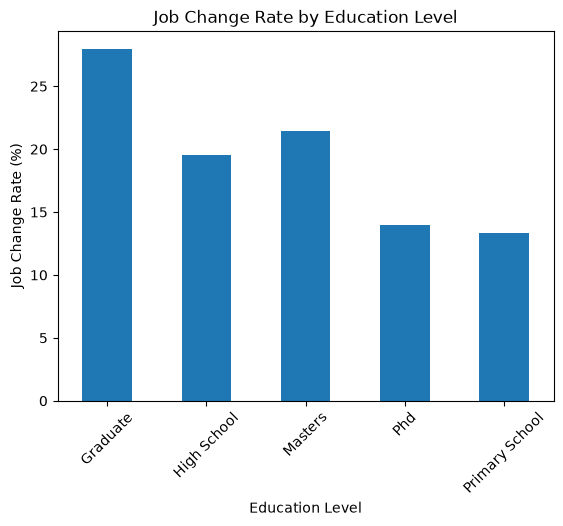

In [90]:
# Exclude candidates with unknown education
education_data = df_clean[
    df_clean["education_level"] != "Unknown"
]

# Calculate job change rates
job_change = education_data.groupby("education_level")["target"].mean() * 100

job_change.plot(kind="bar")

plt.title("Job Change Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Job Change Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
The "Unknown" category was kept during data cleaning to avoid losing information. However, it was excluded from the comparison of education levels because it does not represent an actual qualification. The 460 excluded records remain in the cleaned dataset.